In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
from lifelines.utils import survival_table_from_events
from lifelines import KaplanMeierFitter, WeibullAFTFitter, CoxPHFitter
from lifelines.utils import k_fold_cross_validation, concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

In [3]:
df_gbsg = pd.read_csv("./data/gbsg.csv")
df_hm = pd.read_csv("./data/haberman.csv")
df_sd = pd.read_csv("./data/simulated_data.csv")

In [4]:
def compute_ibs(cph, df, duration_col, event_col):
    # sksurv structured array
    y = Surv.from_arrays(
        event=df[event_col].astype(bool).values,
        time=df[duration_col].values
    )

    t_min = df[duration_col].min()
    t_max = df[duration_col].max()

    # IMPORTANT: times must be strictly < t_max
    times = np.linspace(t_min, t_max * 0.999, 100)

    # lifelines survival predictions (times x samples)
    surv_df = cph.predict_survival_function(df, times=times)

    # Convert to (samples x times)
    surv_preds = surv_df.T.values

    ibs = integrated_brier_score(
        y,          # training data
        y,          # test data (same here)
        surv_preds,
        times
    )

    return ibs

### GBSG

In [5]:
df_gbsg.shape

(686, 12)

In [6]:
df_gbsg.head(10)

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,1,132,49,0,18,2,2,0,0,0,1838,0
1,2,1575,55,1,20,3,16,0,0,0,403,1
2,3,1140,56,1,40,3,3,0,0,0,1603,0
3,4,769,45,0,25,3,1,0,4,0,177,0
4,5,130,65,1,30,2,5,0,36,1,1855,0
5,6,1642,48,0,52,2,11,0,0,0,842,1
6,7,475,48,0,21,3,8,0,0,0,293,1
7,8,973,37,0,20,2,9,0,0,1,42,0
8,9,569,67,1,20,2,1,0,0,1,564,1
9,10,1180,45,0,30,2,1,0,0,0,1093,1


In [7]:
df_gbsg = df_gbsg.drop(['pid', 'Unnamed: 0'], axis=1)

In [8]:
df_gbsg.isna().sum()

age        0
meno       0
size       0
grade      0
nodes      0
pgr        0
er         0
hormon     0
rfstime    0
status     0
dtype: int64

In [9]:
df_gbsg.describe()

,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,53.052478,0.577259,29.329446,2.116618,5.010204,109.995627,96.252187,0.358601,1124.489796,0.435860
std,10.120739,0.494355,14.296217,0.582808,5.475483,202.331552,153.083963,0.479940,642.791948,0.496231
min,21.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,46.000000,0.000000,20.000000,2.000000,1.000000,7.000000,8.000000,0.000000,567.750000,0.000000
50%,53.000000,1.000000,25.000000,2.000000,3.000000,32.500000,36.000000,0.000000,1084.000000,0.000000
75%,61.000000,1.000000,35.000000,2.000000,7.000000,131.750000,114.000000,1.000000,1684.750000,1.000000
max,80.000000,1.000000,120.000000,3.000000,51.000000,2380.000000,1144.000000,1.000000,2659.000000,1.000000


In [10]:
print(df_gbsg["status"].value_counts())

print("\nIn Percentage:")
print(df_gbsg['status'].value_counts(normalize = True) )

status
0    387
1    299
Name: count, dtype: int64

In Percentage:
status
0    0.56414
1    0.43586
Name: proportion, dtype: float64


In [11]:
event_rate = df_gbsg["status"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.44
Censoring rate: 0.56


In [12]:
# Create log features for skewed data
df_gbsg['log_nodes'] = np.log1p(df_gbsg['nodes'])
df_gbsg['log_pgr'] = np.log1p(df_gbsg['pgr'])

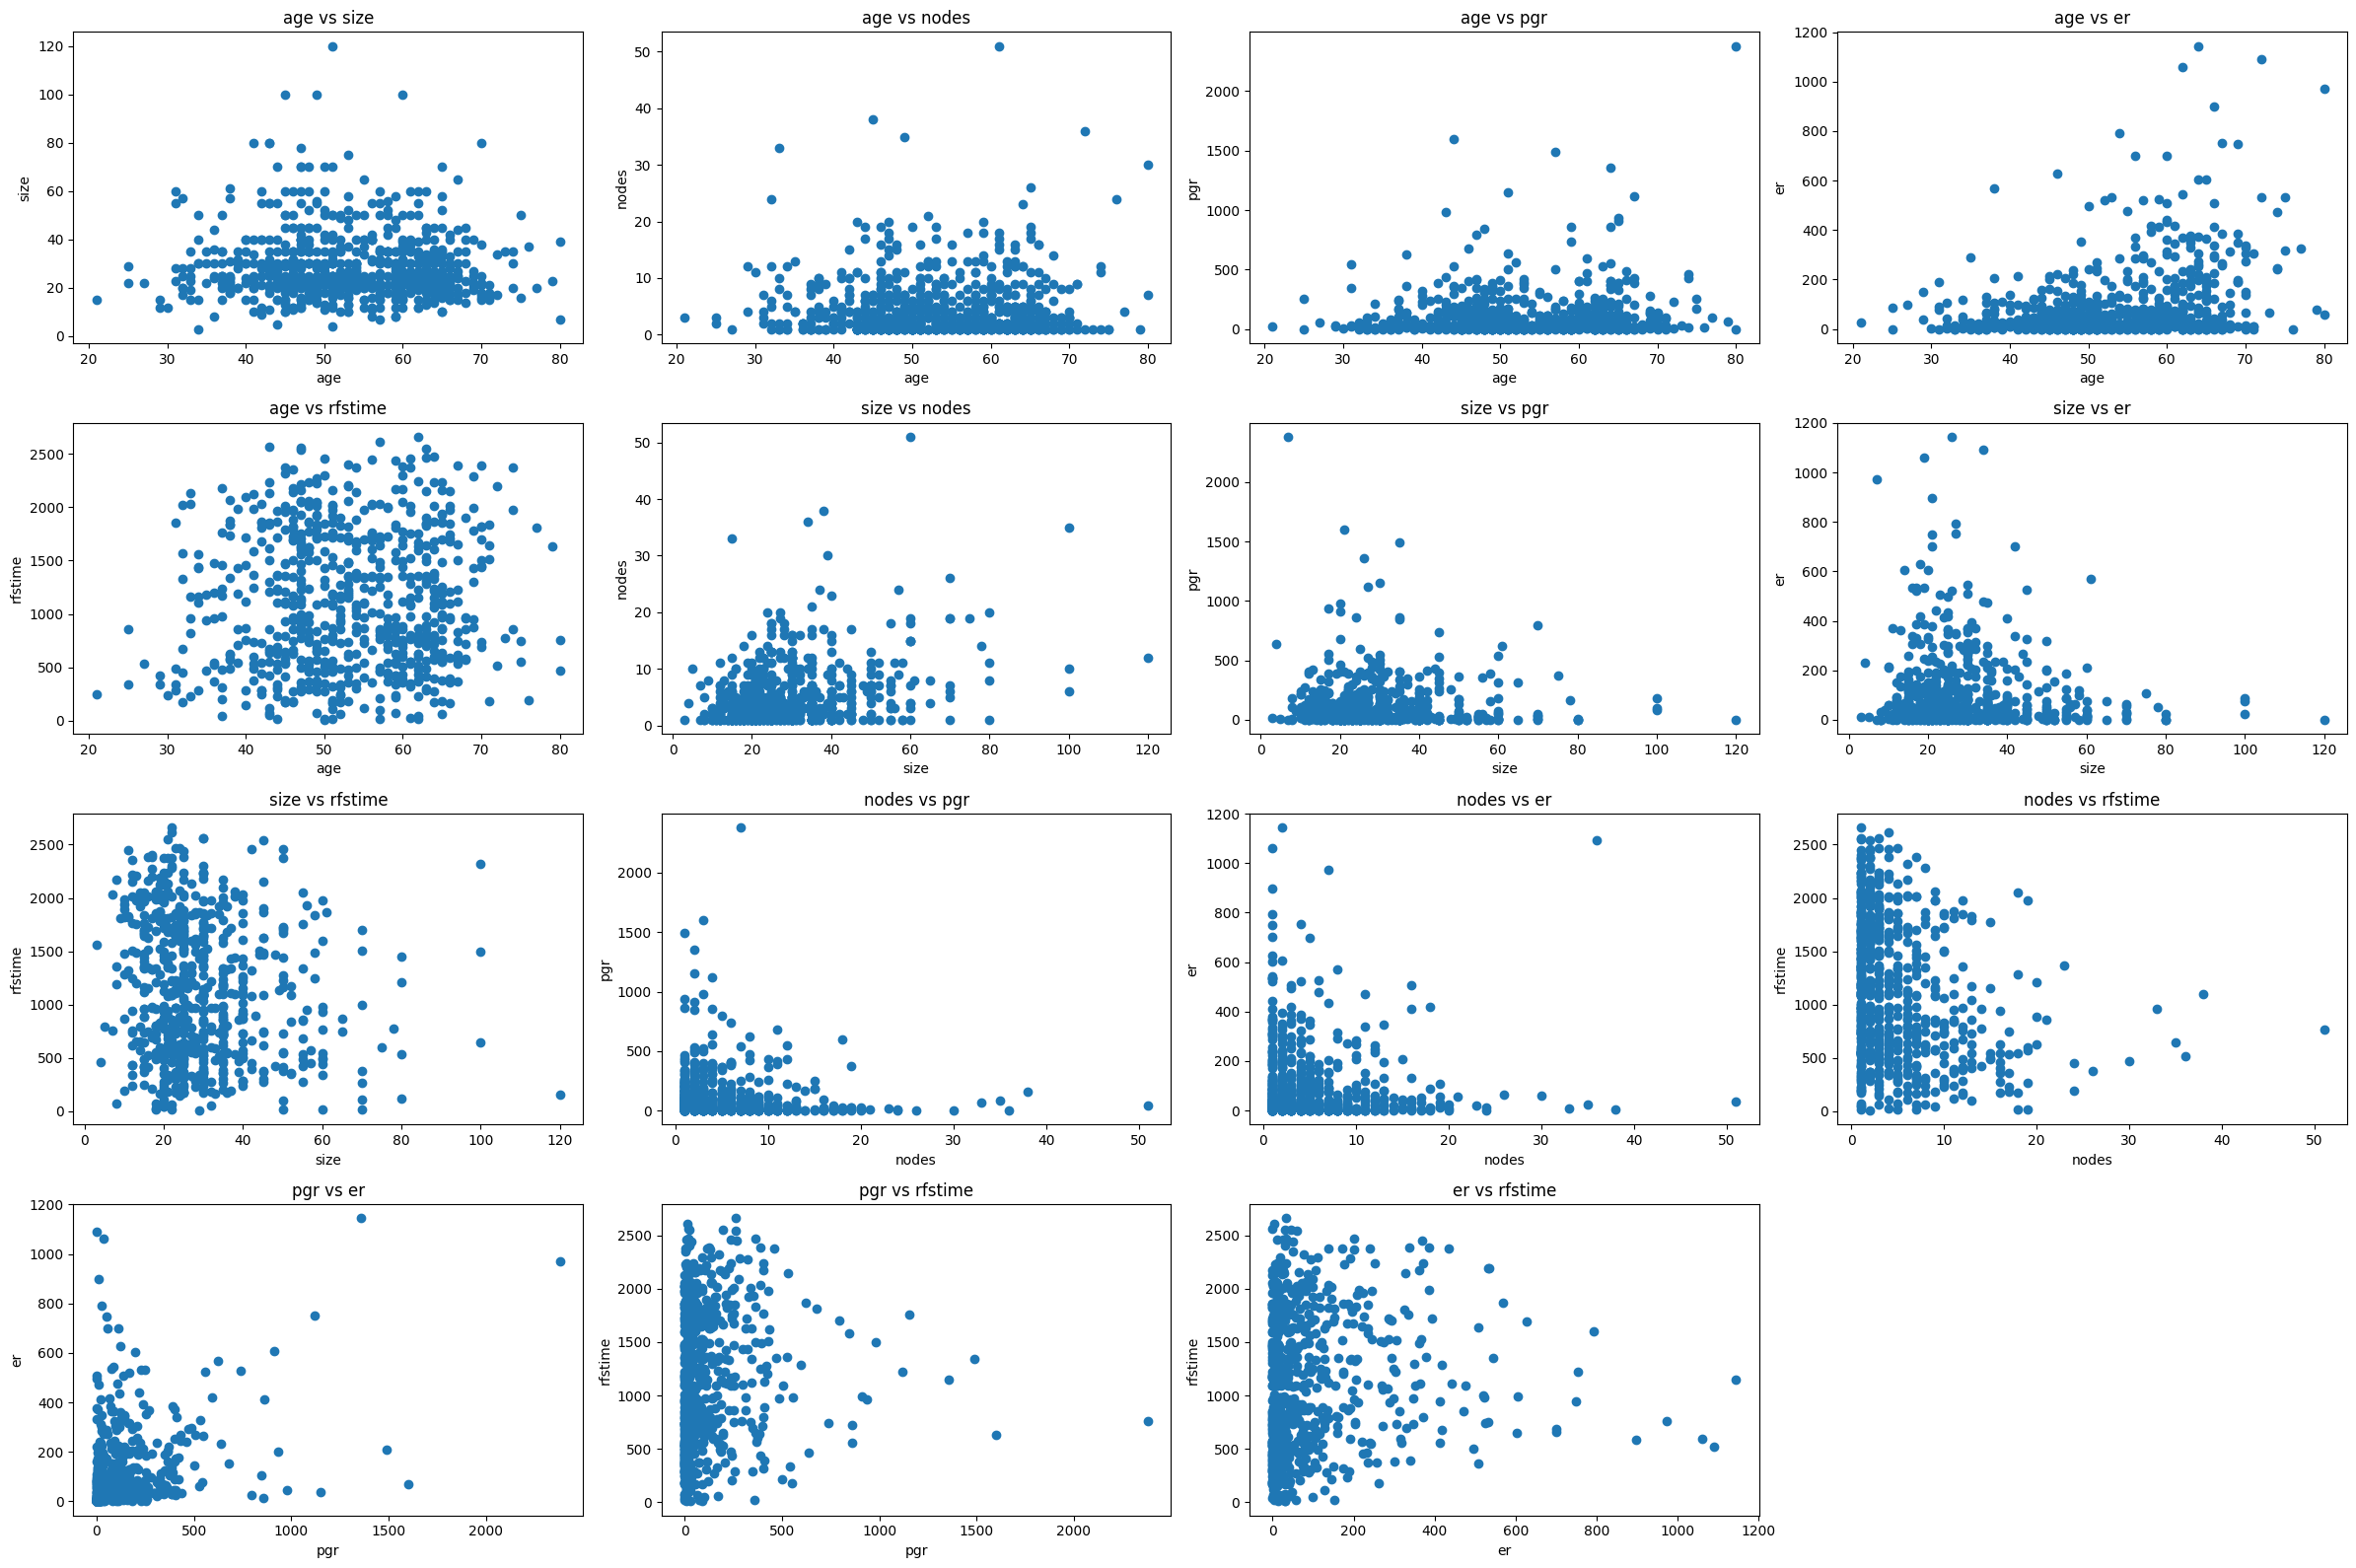

In [13]:
cols = ['age', 'size', 'nodes', 'pgr', 'er', 'rfstime']


pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Grid size (4 columns)
cols_grid = 4
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6*cols_grid, 4*rows_grid))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_gbsg[x], df_gbsg[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

# Turn off empty plots if any
for i in range(len(pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

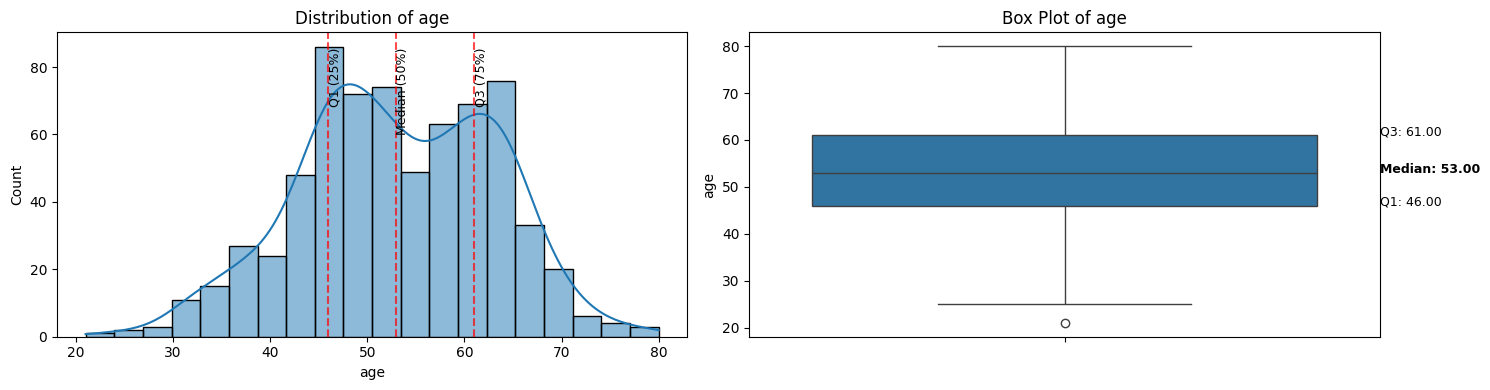

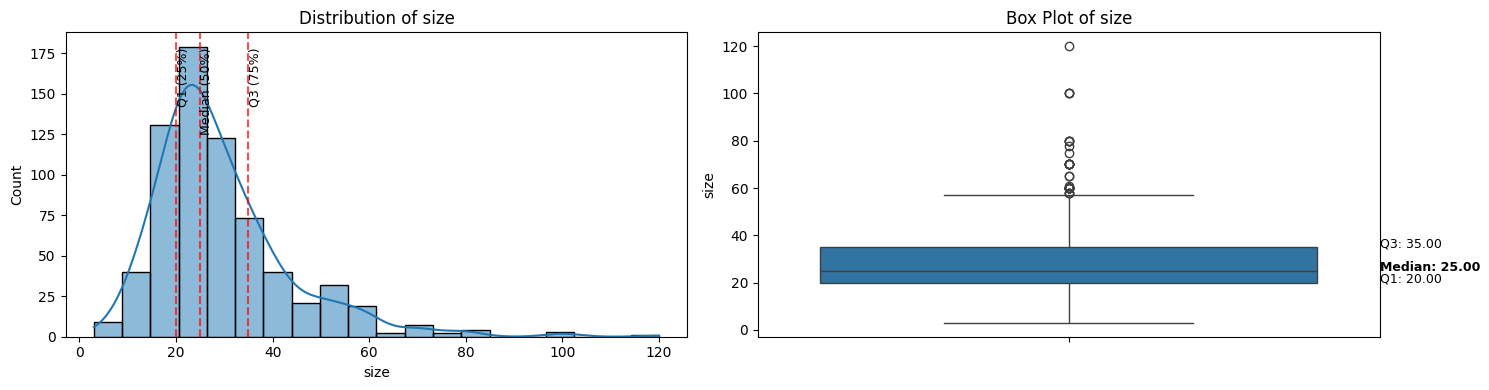

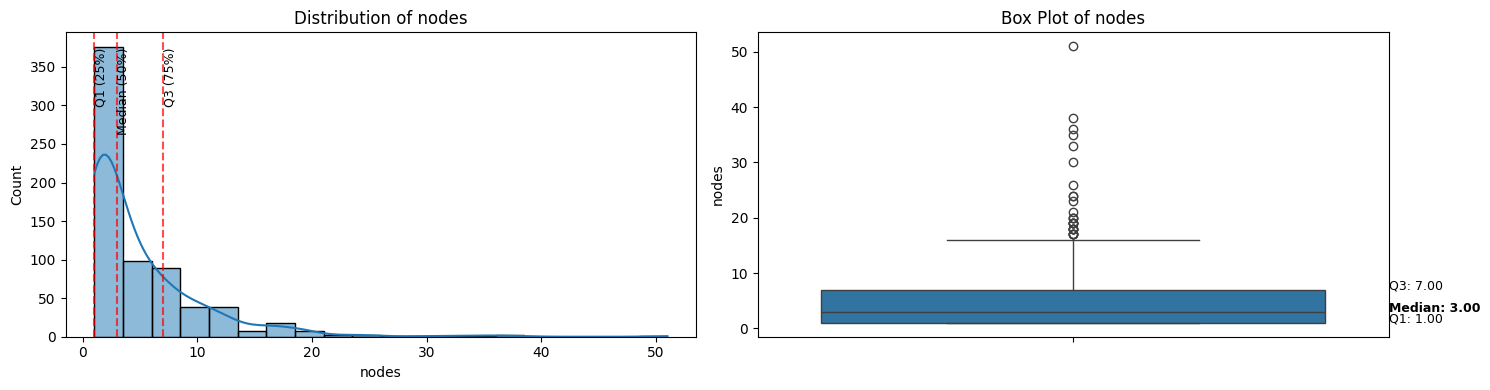

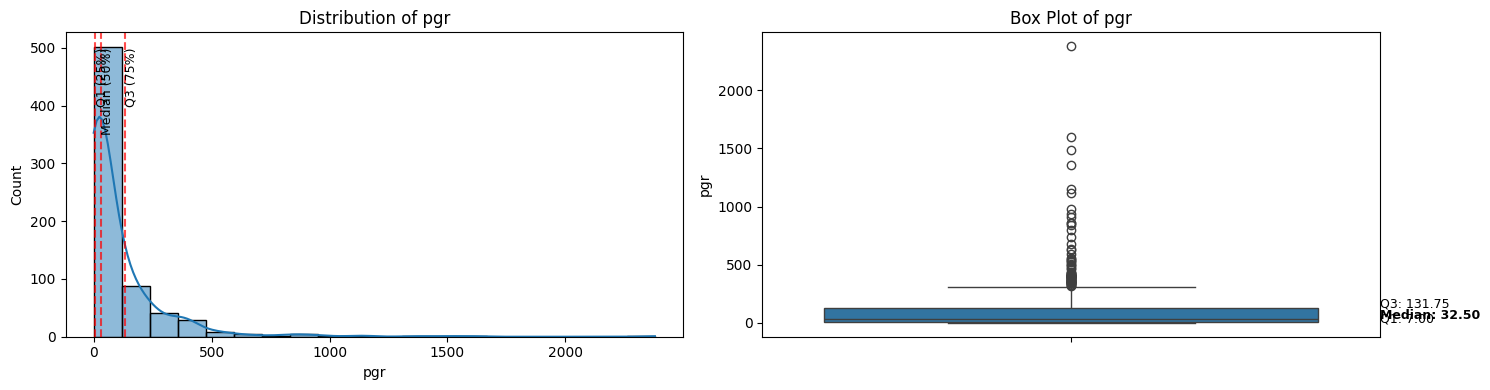

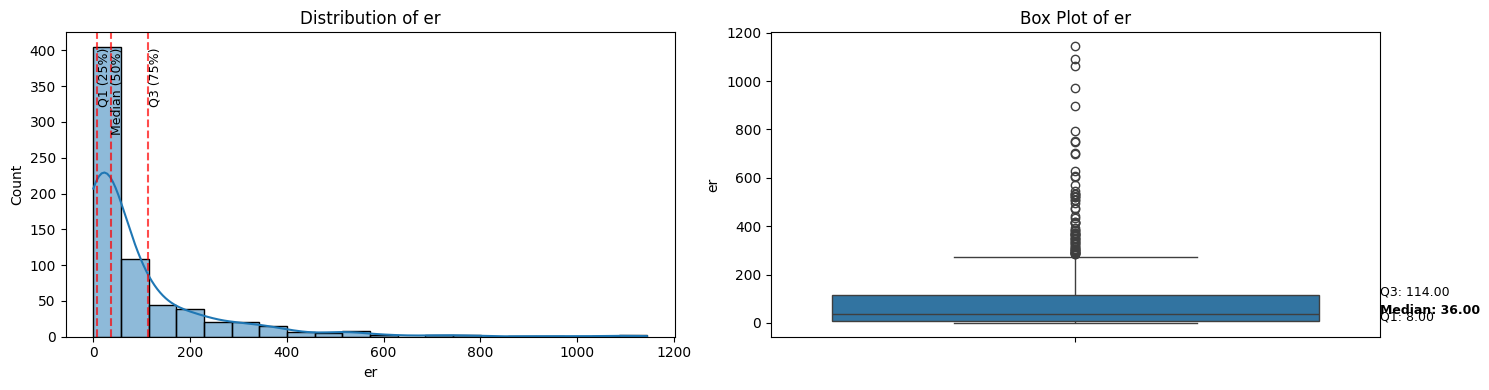

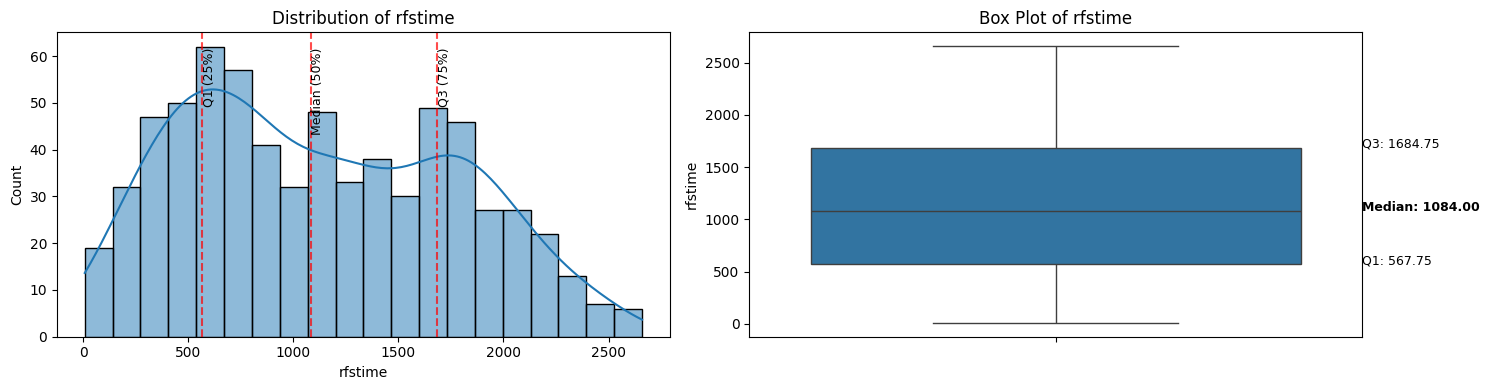

In [14]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Histogram with quantiles
    sns.histplot(data=df_gbsg, x=col, kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
      
    # Plot 2: Box plot with quantile annotations
    sns.boxplot(data=df_gbsg, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    # Add quantile values as text on boxplot
    q1, median, q3 = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

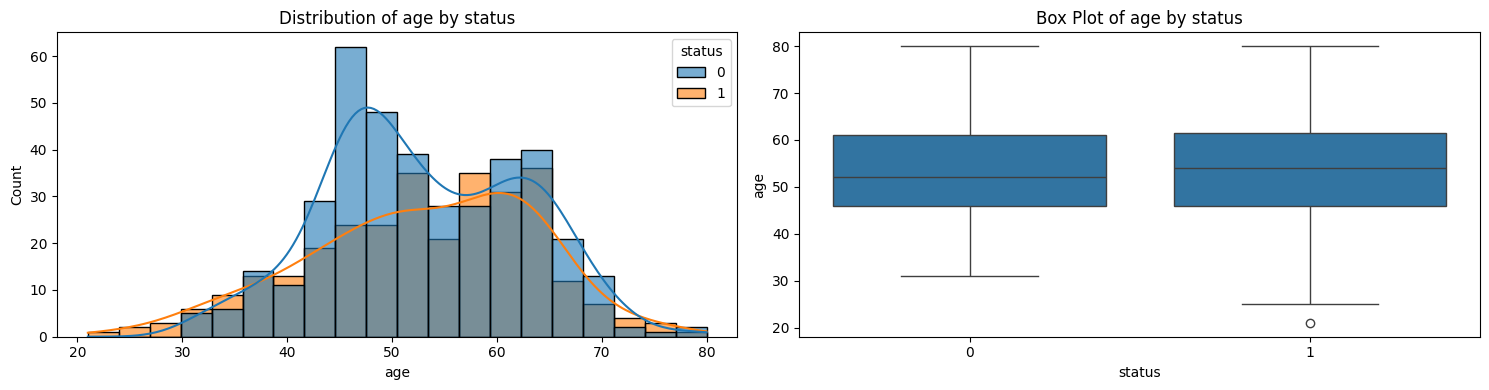

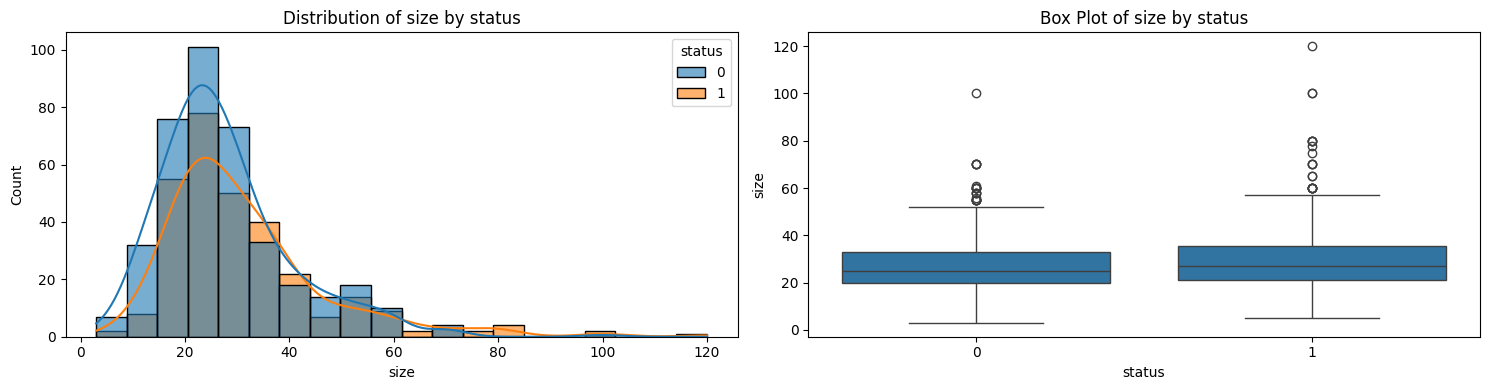

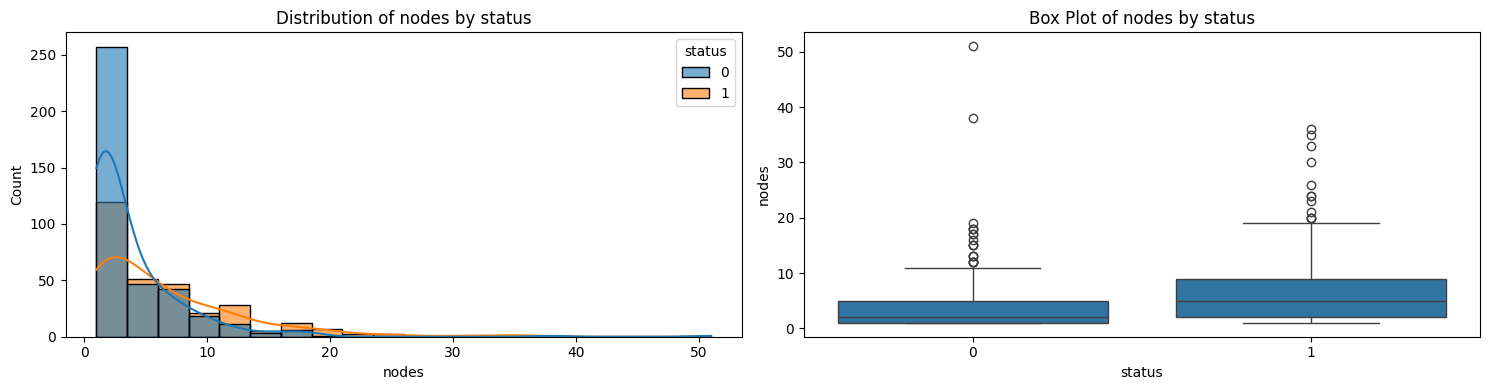

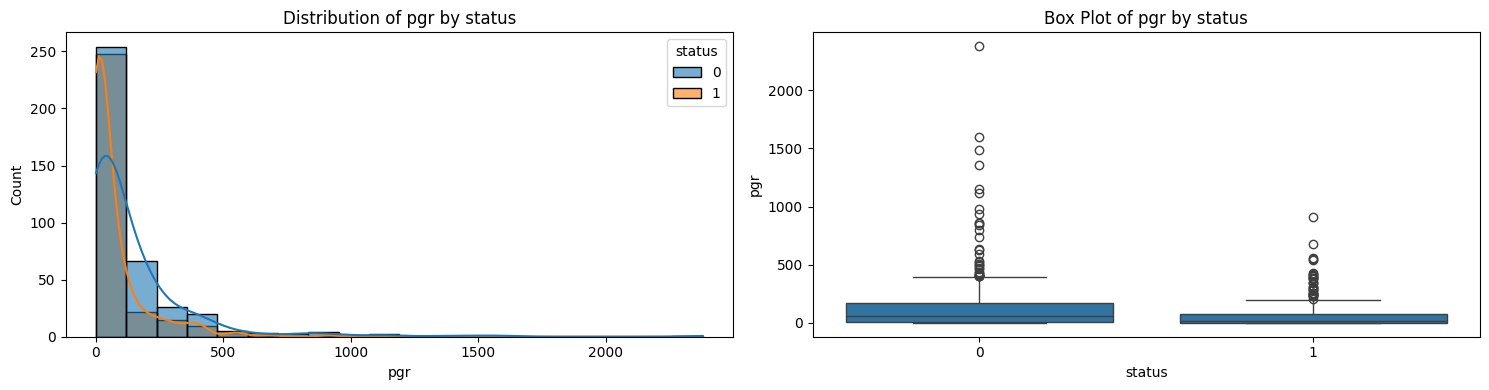

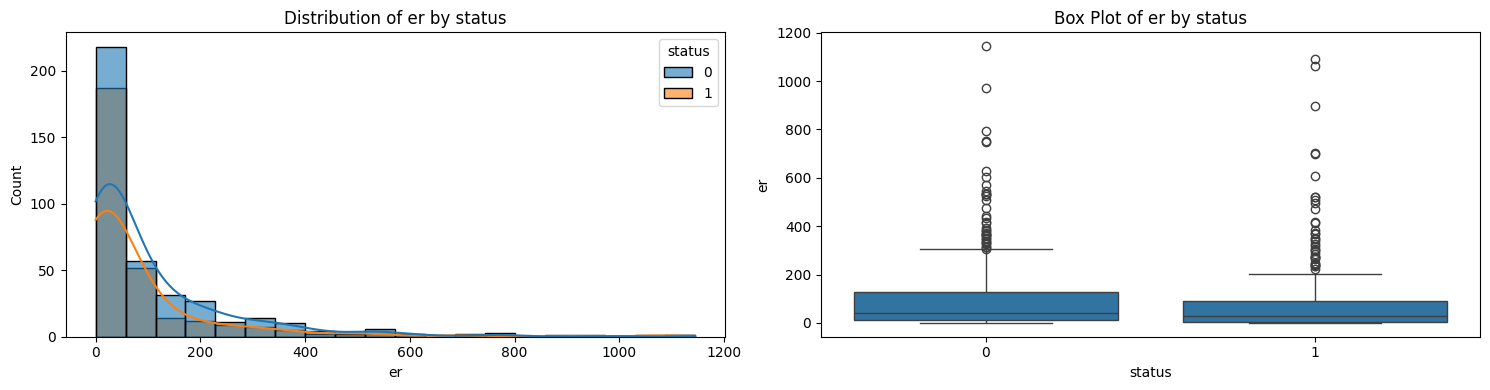

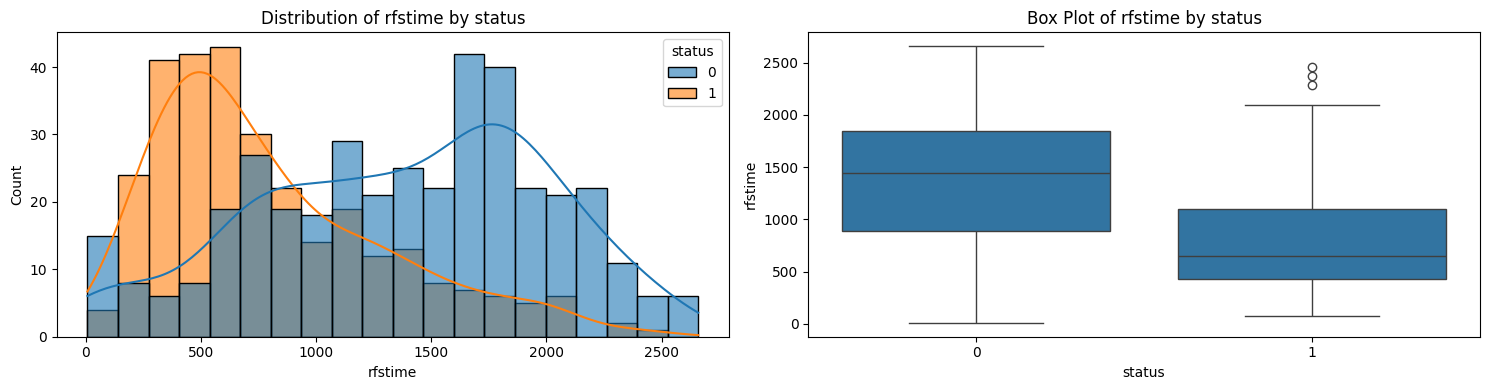

In [15]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms
    sns.histplot(data=df_gbsg, x=col, hue='status', kde=True, bins=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by status")
      
    # Plot 2: Box plots
    sns.boxplot(data=df_gbsg, x='status', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by status")
   
    plt.tight_layout()
    plt.show()

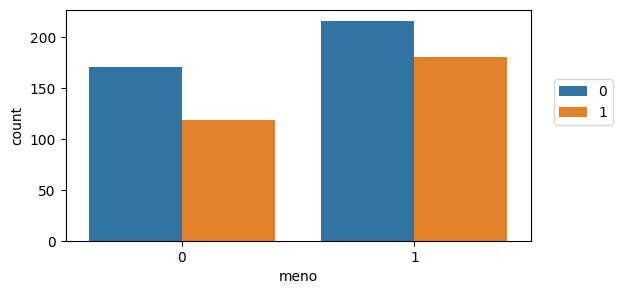

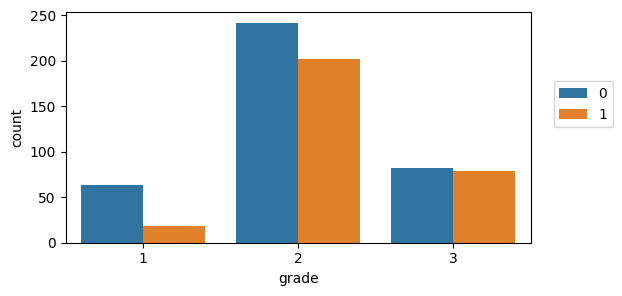

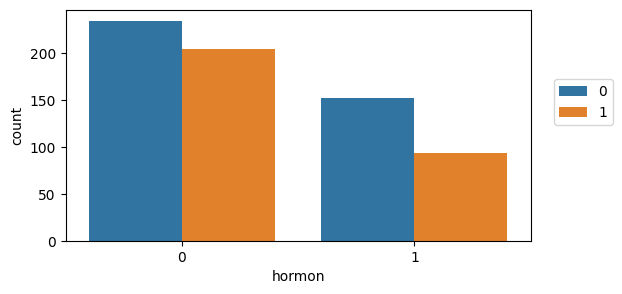

In [16]:
cols_qualitative = ['meno' ,'grade', 'hormon']

for col in cols_qualitative: 
    plt.figure(figsize=(6,3), dpi=100) 
    sns.countplot(data=df_gbsg,x=col,hue ='status') 
    plt.legend(loc=(1.05,0.5))

In [17]:
df_gbsg.corr()

,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status,log_nodes,log_pgr
age,1.000000,0.770076,-0.045412,-0.072318,0.032709,0.084355,0.323132,0.263906,0.053958,-0.004270,0.007447,0.035322
meno,0.770076,1.000000,-0.042027,-0.036384,0.023169,0.018649,0.258860,0.276847,0.024712,0.044034,0.021938,-0.034820
size,-0.045412,-0.042027,1.000000,0.103488,0.327665,-0.027415,-0.081766,-0.027456,-0.138376,0.130978,0.318336,-0.062029
grade,-0.072318,-0.036384,0.103488,1.000000,0.144187,-0.180905,-0.119663,-0.061001,-0.171505,0.131904,0.140752,-0.368936
nodes,0.032709,0.023169,0.327665,0.144187,1.000000,-0.072534,-0.043183,0.016382,-0.256751,0.242287,0.901278,-0.130874
pgr,0.084355,0.018649,-0.027415,-0.180905,-0.072534,1.000000,0.392601,0.052874,0.102729,-0.171596,-0.050293,0.651676
er,0.323132,0.258860,-0.081766,-0.119663,-0.043183,0.392601,1.000000,0.144512,0.065477,-0.061561,-0.078564,0.355978
hormon,0.263906,0.276847,-0.027456,-0.061001,0.016382,0.052874,0.144512,1.000000,0.134838,-0.081044,0.027562,0.018618
rfstime,0.053958,0.024712,-0.138376,-0.171505,-0.256751,0.102729,0.065477,0.134838,1.000000,-0.447103,-0.270136,0.248380
status,-0.004270,0.044034,0.130978,0.131904,0.242287,-0.171596,-0.061561,-0.081044,-0.447103,1.000000,0.273252,-0.215095


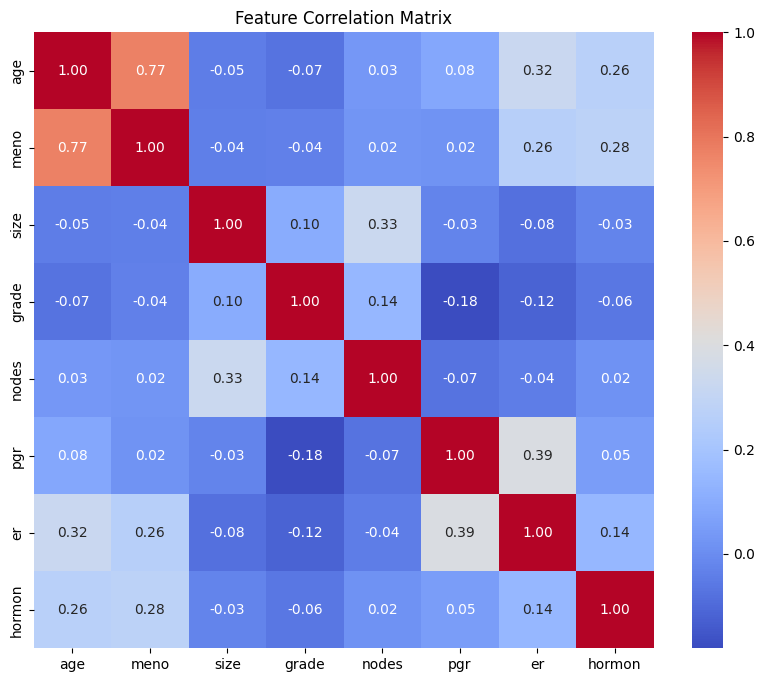

In [18]:
plt.figure(figsize=(10, 8))

# Compute correlation matrix
corr = df_gbsg.drop(['rfstime', 'status', 'log_nodes', 'log_pgr'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

#### gbsg modelling

In [19]:
T = df_gbsg['rfstime']
E = df_gbsg['status']

survival_table_from_events(T,E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,686,686
8.0,1,0,1,0,686
15.0,1,0,1,0,685
16.0,1,0,1,0,684
17.0,2,0,2,0,683
...,...,...,...,...,...
2551.0,1,0,1,0,5
2556.0,1,0,1,0,4
2563.0,1,0,1,0,3


In [20]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 686 total observations, 387 right-censored observations>

In [21]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
8.0,1.000000
15.0,1.000000
16.0,1.000000
17.0,1.000000
...,...
2551.0,0.342758
2556.0,0.342758
2563.0,0.342758


<Axes: xlabel='timeline'>

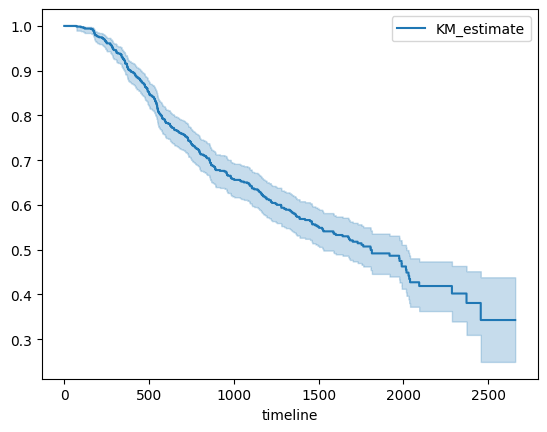

In [22]:
kmf.plot_survival_function()

In [23]:
wft = WeibullAFTFitter()
wft.fit(df_gbsg, duration_col='rfstime', event_col='status')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
   number of observations = 686
number of events observed = 299
           log-likelihood = -2564.30
         time fit was run = 2026-02-06 04:50:26 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        er        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        grade     -0.13      0.88      0.08           -0.28            0.02                0.76                1.02
        hormon     0.29      1.33      0.09            0.11            0.47                1.12                1.59
        log_nodes -0.56      0.57      0.13           -0.81           -0.31                0.44                0.73
        log_pgr    0.10      1.10      0.03            0.04            0.16                1.04                1.18
        meno      -0.14      0.87      0.13           -0.39            0.11                0.68                1.11
        nodes      0.01      1.01      0.01           -0.02            0.04                0.98                1.04
        pgr        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        size      -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Intercept  8.16   3501.65      0.39            7.40            8.92             1636.93             7490.60
rho_    Intercept  0.35      1.42      0.05            0.26            0.45                1.29                1.56

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00  0.95   0.34      1.55
        er           0.00 -1.57   0.12      3.11
        grade        0.00 -1.67   0.09      3.40
        hormon       0.00  3.17 <0.005      9.35
        log_nodes    0.00 -4.37 <0.005     16.33
        log_pgr      0.00  3.08 <0.005      8.91
        meno         0.00 -1.12   0.26      1.92
        nodes        0.00  0.81   0.42      1.25
        pgr          0.00  1.52   0.13      2.96
        size         0.00 -1.11   0.27      1.91
        Intercept    0.00 21.03 <0.005    323.90
rho_    Intercept    0.00  7.28 <0.005     41.47
---
Concordance = 0.70
AIC = 5152.59
log-likelihood ratio test = 145.96 on 10 df
-log2(p) of ll-ratio test = 85.03

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

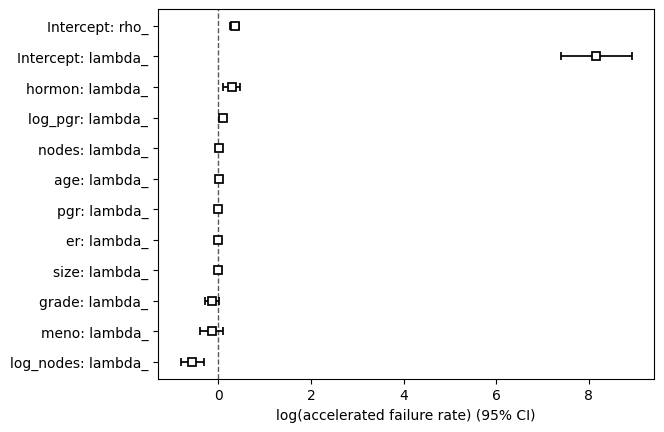

In [24]:
wft.plot()

In [25]:
features = ['log_nodes', 'log_pgr', 'age', 'meno', 'size', 'grade', 'er', 'hormon', 'rfstime', 'status']

In [26]:
# saving the dataframe
df_gbsg[features].to_csv(r'./data/preprocess-data/preprocess_gbsg.csv')

In [27]:
cph = CoxPHFitter()
cph.fit(df_gbsg[features], duration_col='rfstime', event_col='status', strata=['meno' ,'grade', 'hormon'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
                   strata = ['meno', 'grade', 'hormon']
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1118.62
         time fit was run = 2026-02-06 04:50:26 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
log_nodes  0.59      1.80      0.08            0.42            0.75                1.53                2.12
log_pgr   -0.18      0.83      0.03           -0.25           -0.12                0.78                0.89
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
size       0.01      1.01      0.00           -0.00            0.01                1.00                1.01
er         0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
log_nodes    0.00  7.02 <0.005     38.74
log_pgr      0.00 -5.37 <0.005     23.60
age          0.00 -0.93   0.35      1.51
size         0.00  1.38   0.17      2.58
er           0.00  1.04   0.30      1.75
---
Concordance = 0.67
Partial AIC = 2247.24
log-likelihood ratio test = 96.11 on 5 df
-log2(p) of ll-ratio test = 61.31


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                test_statistic      p  -log2(p)
age       km              2.44   0.12      3.08
          rank            9.49 <0.005      8.92
er        km              0.71   0.40      1.32
          rank            0.02   0.88      0.19
log_nodes km              0.54   0.46      1.11
          rank            0.22   0.64      0.65
log_pgr   km              1.28   0.26      1.95
          rank            0.08   0.78      0.36
size      km              0.02   0.89      0.16
          rank            0.06   0.81      0.31



1. Variable 'age' failed the non-proportional test: p-value is 0.0021.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifel

[[<Axes: xlabel='rank-transformed time\n(p=0.6373)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4639)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7814)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2588)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0021)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1186)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8057)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8949)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8778)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4009)'>]]

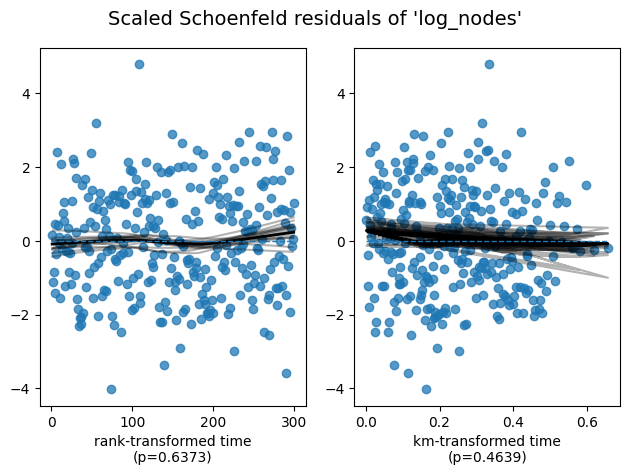

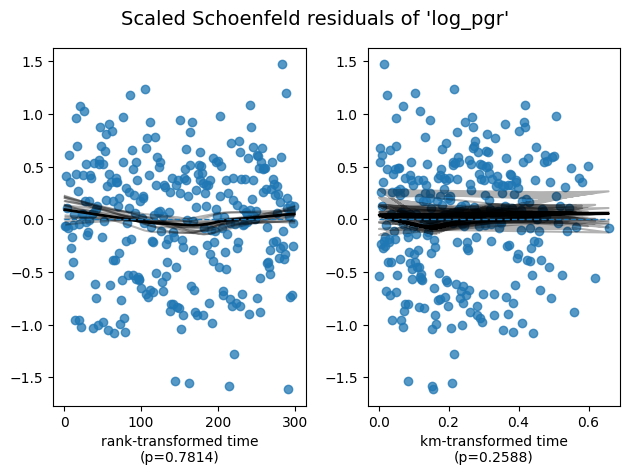

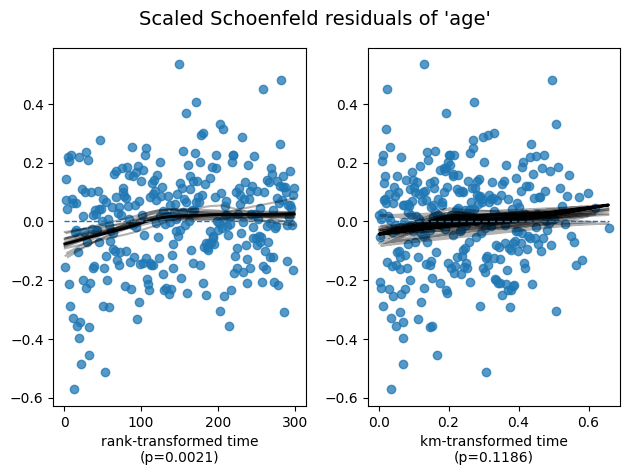

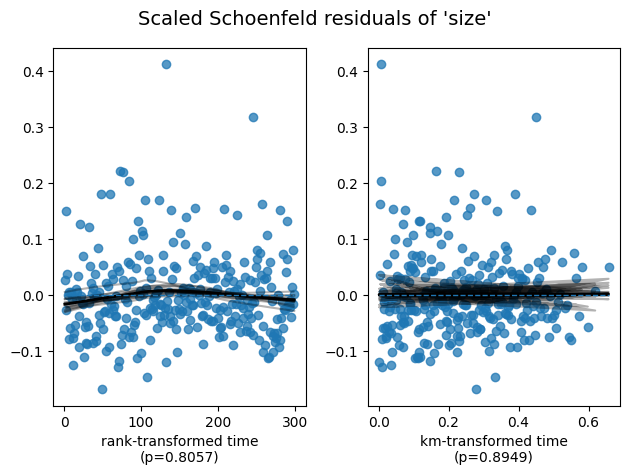

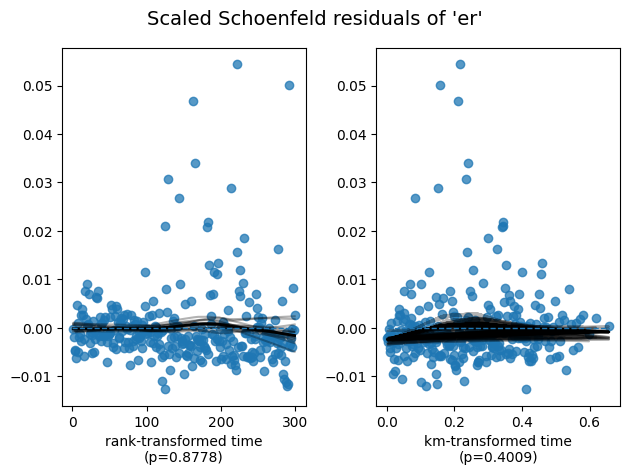

In [28]:
cph.check_assumptions(df_gbsg[features], show_plots=True, p_value_threshold=0.05)

In [29]:
scores = k_fold_cross_validation(
    cph, df_gbsg, duration_col='rfstime', event_col='status', k=5
)

print("Average C-index:", np.mean(scores))

Average C-index: -0.9731114462195416


In [30]:
pred = cph.predict_partial_hazard(df_gbsg)
c_index_gbsg = concordance_index(df_gbsg["rfstime"], -pred, df_gbsg["status"])
print("CoxPH C-index:", c_index_gbsg)

CoxPH C-index: 0.6906561861248046


In [31]:
ibs_gbsg = compute_ibs(
    cph=cph,
    df=df_gbsg,
    duration_col="rfstime",
    event_col="status"
)

print("CoxPH IBS:", ibs_gbsg)

CoxPH IBS: 0.23410934347027074


In [32]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 1686.2980783556457


### Haberman

In [33]:
df_hm.shape

(305, 4)

In [34]:
df_hm.head(10).transpose()

,0,1,2,3,4,5,6,7,8,9
30,30,30,31,31,33,33,34,34,34,34
64,62,65,59,65,58,60,59,66,58,60
1,3,0,2,4,10,0,0,9,30,1
1.1,1,1,1,1,1,1,2,2,1,1


In [35]:
df_hm.isna().sum()

30     0
64     0
1      0
1.1    0
dtype: int64

In [36]:
df_hm.columns = ["PatientAge", "PatientYearOperation", "NumberAxillaryNodes", "SurvivalStatus"] # give name to columns
df_hm.head(5)

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [37]:
df_hm.describe()

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [38]:
df_hm["SurvivalStatus"] = np.where(df_hm["SurvivalStatus"] == 2, 1, 0)

In [39]:
print(df_hm["SurvivalStatus"].value_counts())

print("\nIn Percentage:")
print(df_hm['SurvivalStatus'].value_counts(normalize = True) )

SurvivalStatus
0    224
1     81
Name: count, dtype: int64

In Percentage:
SurvivalStatus
0    0.734426
1    0.265574
Name: proportion, dtype: float64


In [40]:
event_rate = df_hm["SurvivalStatus"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.27
Censoring rate: 0.73


In [41]:
df_hm['LogNodes'] = np.log1p(df_hm['NumberAxillaryNodes'])

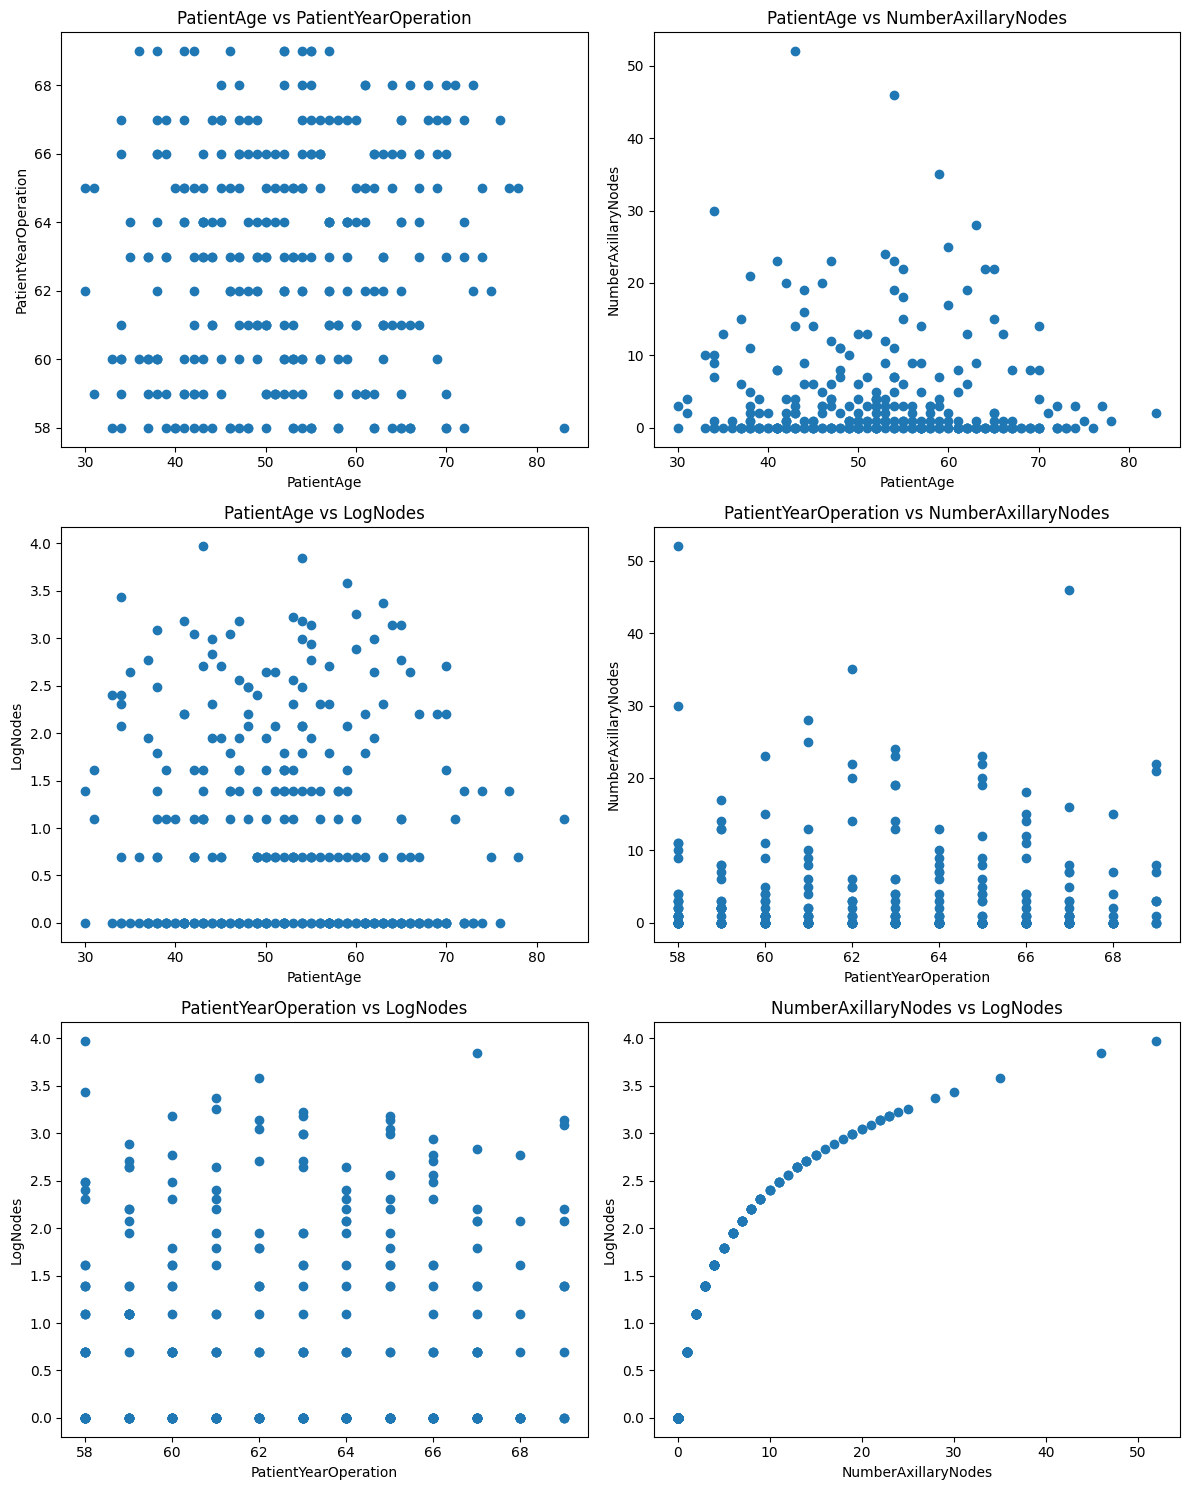

In [42]:
cols = ['PatientAge', 'PatientYearOperation', 'NumberAxillaryNodes', 'LogNodes']

pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Two plots per row
n_cols = 2
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()  # make indexing easy

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_hm[x], df_hm[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

# Hide any unused subplots
for ax in axes[len(pairs):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

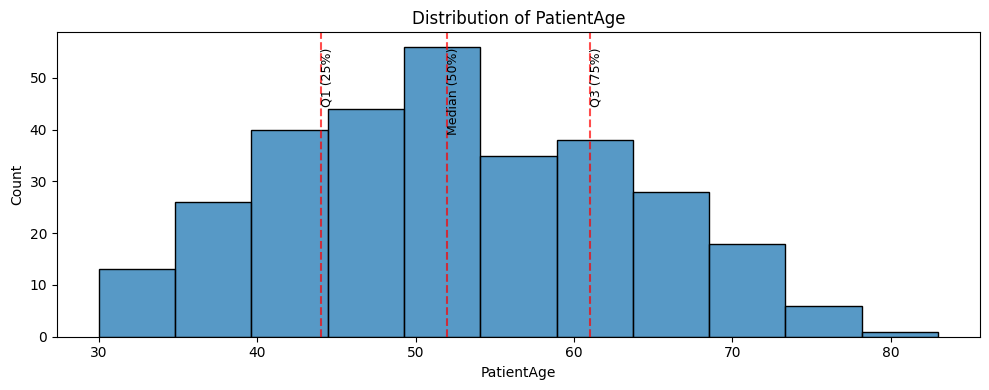

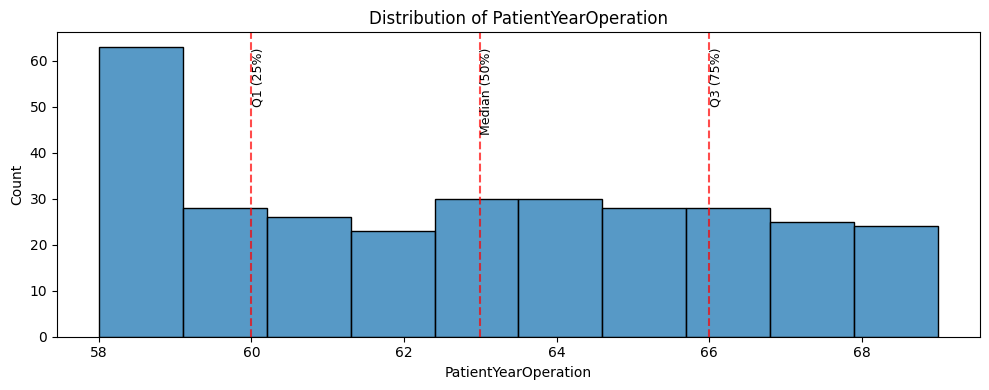

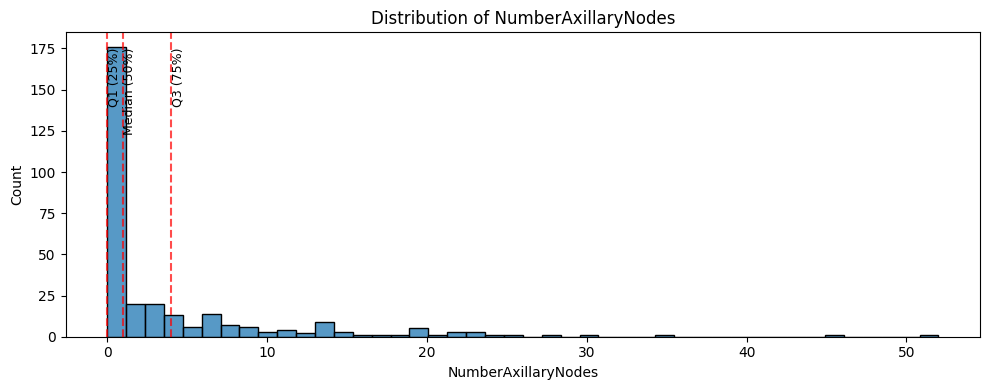

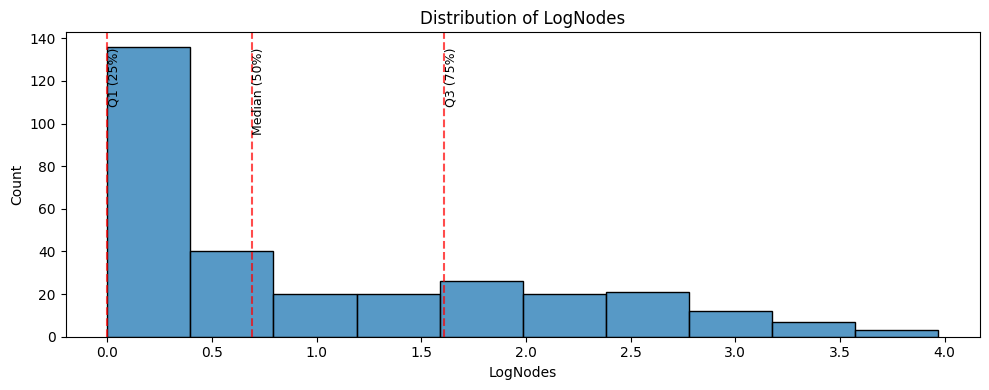

In [43]:
for col in cols:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
   
    # Overlapping histogram with quantiles
    sns.histplot(data=df_hm, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_hm[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        ax.axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(q_val, ax.get_ylim()[1]*0.95, label, 
                rotation=90, verticalalignment='top', fontsize=9)
   
    plt.tight_layout()
    plt.show()

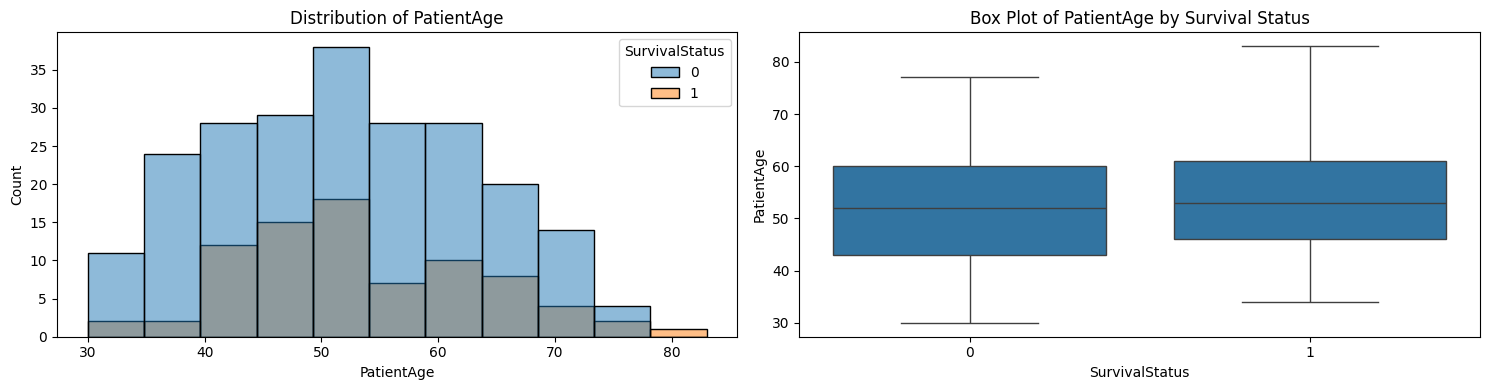

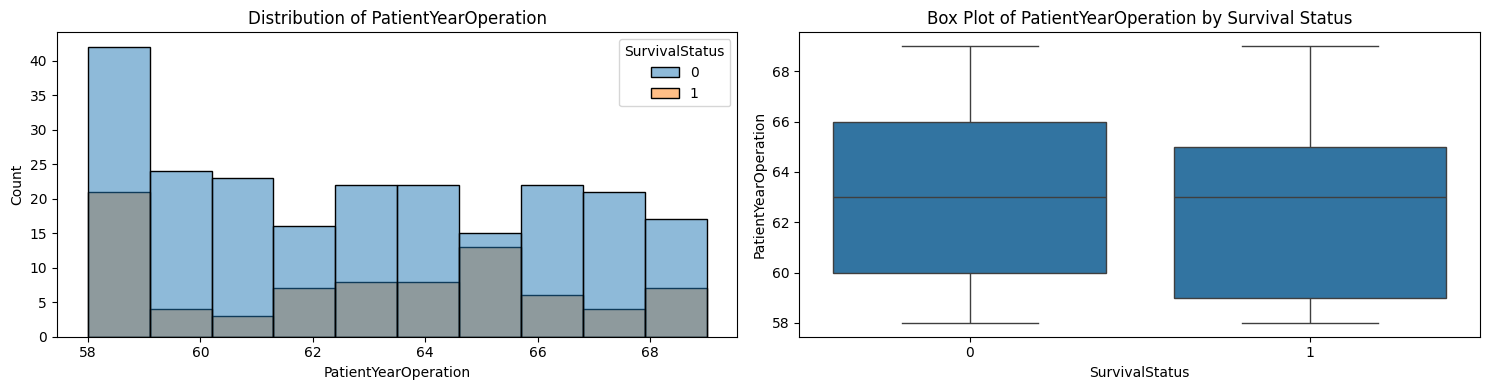

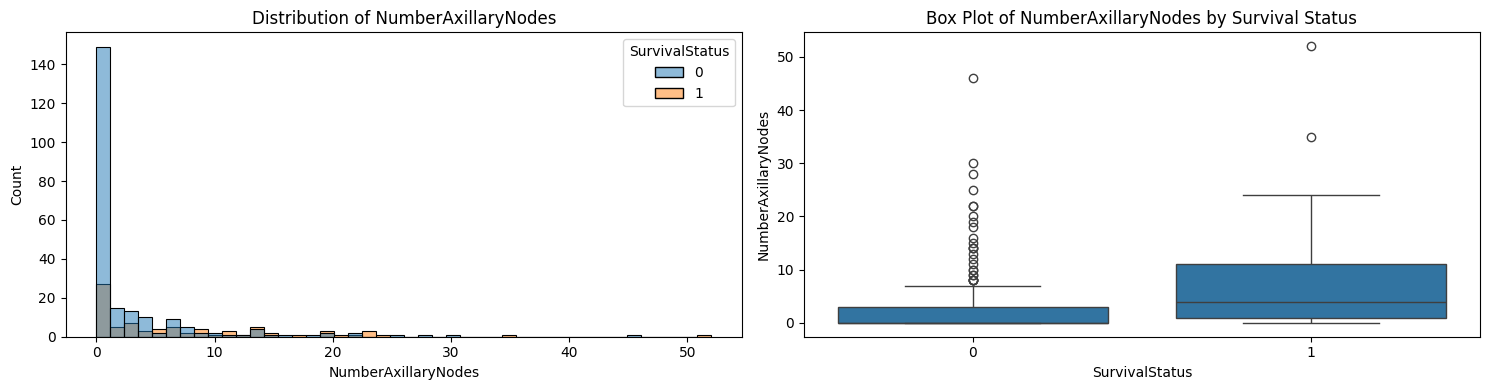

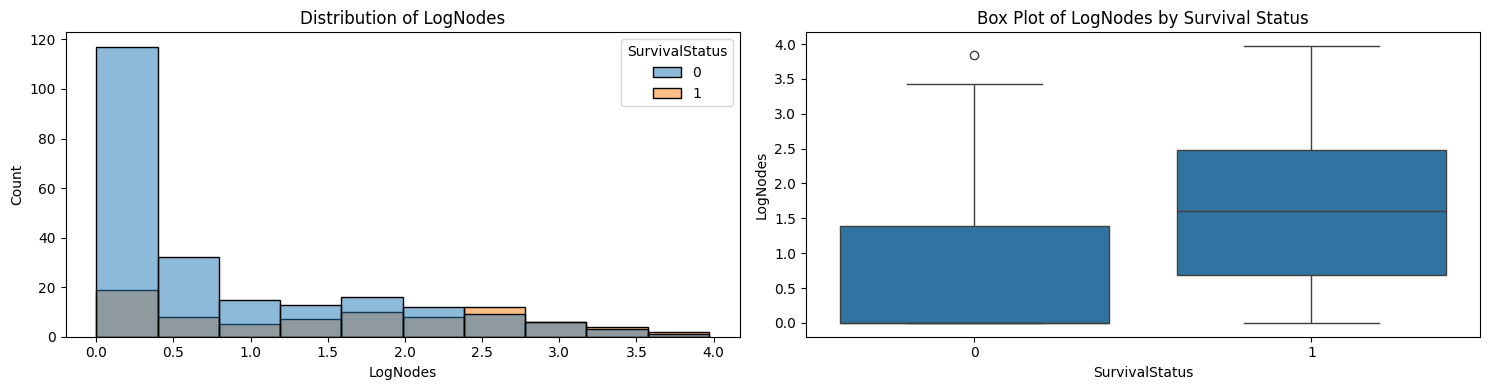

In [44]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms
    sns.histplot(data=df_hm, x=col, ax=axes[0], hue='SurvivalStatus')
    axes[0].set_title(f"Distribution of {col}")
   
    # Plot 2: Box plot by survival status
    sns.boxplot(data=df_hm, x='SurvivalStatus', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by Survival Status")
   
    plt.tight_layout()
    plt.show()

In [45]:
df_hm.corr().abs()

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus,LogNodes
PatientAge,1.000000,0.092623,0.066548,0.064351,0.097061
PatientYearOperation,0.092623,1.000000,0.003277,0.004076,0.016857
NumberAxillaryNodes,0.066548,0.003277,1.000000,0.286191,0.868229
SurvivalStatus,0.064351,0.004076,0.286191,1.000000,0.337705
LogNodes,0.097061,0.016857,0.868229,0.337705,1.000000


#### haberman modelling

In [46]:
T = df_hm['PatientAge']
E = df_hm['SurvivalStatus']

survival_table_from_events(T,E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,305,305
30.0,2,0,2,0,305
31.0,2,0,2,0,303
33.0,2,0,2,0,301
34.0,7,2,5,0,299
35.0,2,0,2,0,292
36.0,2,0,2,0,290
37.0,6,0,6,0,288
38.0,10,1,9,0,282


In [47]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 305 total observations, 224 right-censored observations>

In [48]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
30.0,1.000000
31.0,1.000000
33.0,1.000000
34.0,0.993311
35.0,0.993311
36.0,0.993311
37.0,0.993311
38.0,0.989789


<Axes: xlabel='timeline'>

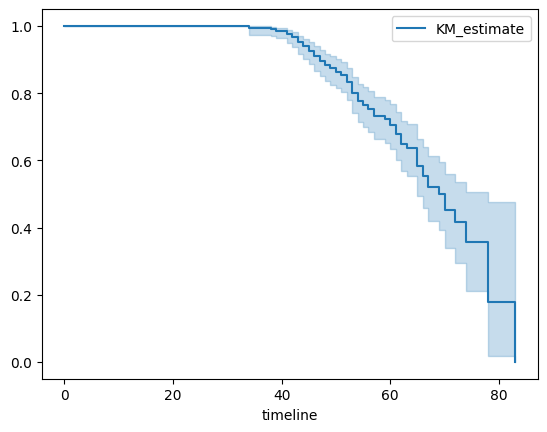

In [49]:
kmf.plot_survival_function()

In [50]:
wft = WeibullAFTFitter()
wft.fit(df_hm, duration_col='PatientAge', event_col='SurvivalStatus')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientAge'
                event col = 'SurvivalStatus'
   number of observations = 305
number of events observed = 81
           log-likelihood = -386.79
         time fit was run = 2026-02-06 04:50:34 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                             
lambda_ LogNodes             -0.13      0.88      0.04           -0.20           -0.06                0.82                0.94
        NumberAxillaryNodes   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
        PatientYearOperation  0.00      1.00      0.01           -0.01            0.01                0.99                1.01
        Intercept             4.16     63.82      0.35            3.46            4.85               31.85              127.88
rho_    Intercept             1.82      6.16      0.08            1.66            1.98                5.25                7.23

                              cmp to     z      p  -log2(p)
param   covariate                                          
lambda_ LogNodes                0.00 -3.55 <0.005     11.35
        NumberAxillaryNodes     0.00  0.98   0.33      1.61
        PatientYearOperation    0.00  0.68   0.50      1.00
        Intercept               0.00 11.72 <0.005    102.95
rho_    Intercept               0.00 22.39 <0.005    366.30
---
Concordance = 0.65
AIC = 783.57
log-likelihood ratio test = 38.83 on 3 df
-log2(p) of ll-ratio test = 25.66

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

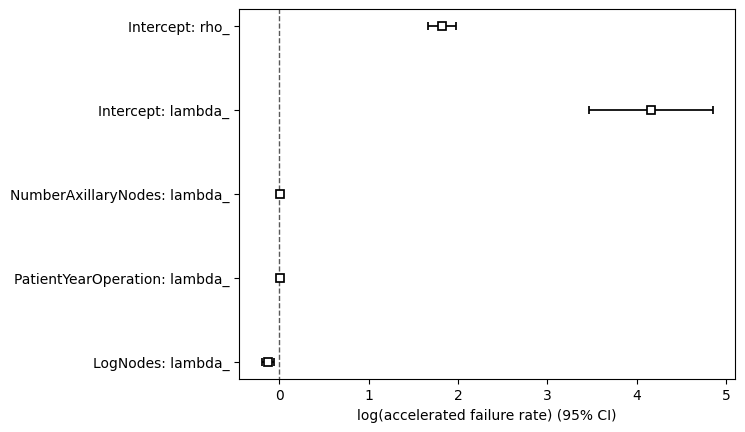

In [51]:
wft.plot()

In [52]:
features = ['PatientAge', 'PatientYearOperation', 'LogNodes', 'SurvivalStatus']

In [53]:
# saving the dataframe
df_hm[features].to_csv(r'./data/preprocess-data/preprocess_haberman.csv')

In [54]:
cph = CoxPHFitter()
cph.fit(df_hm[features], duration_col='PatientAge', event_col='SurvivalStatus')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientAge'
                event col = 'SurvivalStatus'
      baseline estimation = breslow
   number of observations = 305
number of events observed = 81
   partial log-likelihood = -362.22
         time fit was run = 2026-02-06 04:50:35 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
PatientYearOperation -0.02      0.98      0.04           -0.09            0.05                0.91                1.05
LogNodes              0.58      1.78      0.10            0.39            0.76                1.48                2.15

                      cmp to     z      p  -log2(p)
covariate                                          
PatientYearOperation    0.00 -0.67   0.50      1.00
LogNodes                0.00  6.03 <0.005     29.16
---
Concordance = 0.65
Partial AIC = 728.43
log-likelihood ratio test = 35.25 on 2 df
-log2(p) of ll-ratio test = 25.43


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.1946)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3092)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0854)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2492)'>]]

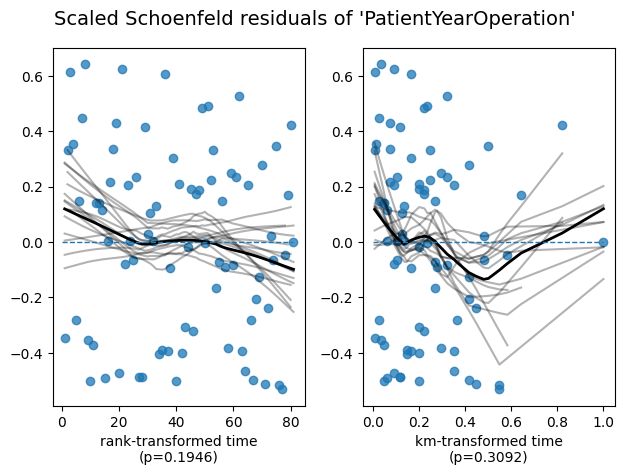

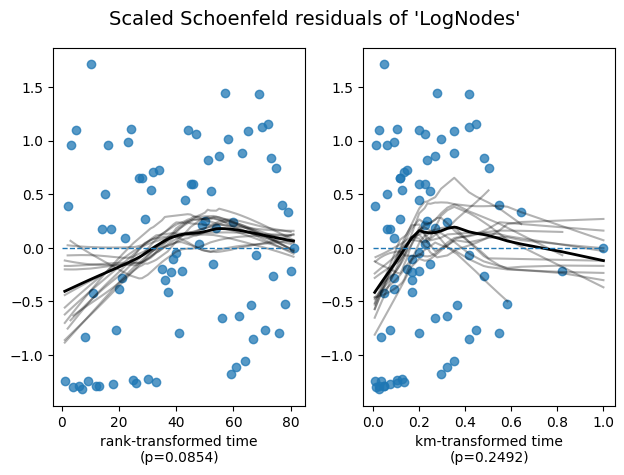

In [55]:
cph.check_assumptions(df_hm[features], show_plots=True, p_value_threshold=0.05)

In [56]:
scores = k_fold_cross_validation(
    cph, df_hm, duration_col='PatientAge', event_col='SurvivalStatus', k=5
)

print("Average C-index:", np.mean(scores))

Average C-index: -0.7853114270419932


In [57]:
pred = cph.predict_partial_hazard(df_hm)
c_index_hm = concordance_index(df_hm["PatientAge"], -pred, df_hm["SurvivalStatus"])
print("CoxPH C-index:", c_index_hm)

CoxPH C-index: 0.6532680290491472


In [58]:
ibs_hm = compute_ibs(
    cph=cph,
    df=df_hm,
    duration_col="PatientAge",      # confirm this is survival time
    event_col="SurvivalStatus"
)

print("CoxPH IBS:", ibs_hm)

CoxPH IBS: 0.12975754728754588


In [59]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 563.6691480200044


### Simulated Data

In [60]:
df_sd.shape

(200, 5)

In [61]:
df_sd.head(10)

,Age,Treatment,Sex,Time,Event
0,54.967142,1,1,0.075964,1
1,48.617357,1,0,0.196966,1
2,56.476885,1,0,0.226271,1
3,65.230299,1,1,0.074202,1
4,47.658466,0,0,0.190551,1
5,47.658630,0,1,0.253558,1
6,65.792128,1,0,0.095786,1
7,57.674347,1,1,0.631463,0
8,45.305256,1,0,0.117190,1
9,55.425600,1,1,0.514171,1


In [62]:
df_sd.isna().sum()

Age          0
Treatment    0
Sex          0
Time         0
Event        0
dtype: int64

In [63]:
df_sd['Log_age'] = np.log1p(df_sd['Age'])

In [64]:
df_sd.describe()

,Age,Treatment,Sex,Time,Event,Log_age
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,49.592290,0.520000,0.500000,0.624313,0.705000,3.906338
std,9.310039,0.500854,0.501255,0.732027,0.457187,0.189906
min,23.802549,0.000000,0.000000,0.004059,0.000000,3.210946
25%,42.948723,0.000000,0.000000,0.151343,0.000000,3.783023
50%,49.958081,1.000000,0.500000,0.398990,1.000000,3.931002
75%,55.008525,1.000000,1.000000,0.832125,1.000000,4.025503
max,77.201692,1.000000,1.000000,4.463726,1.000000,4.359291


In [65]:
print(df_sd["Event"].value_counts())

print("\nIn Percentage:")
print(df_sd['Event'].value_counts(normalize = True))

Event
1    141
0     59
Name: count, dtype: int64

In Percentage:
Event
1    0.705
0    0.295
Name: proportion, dtype: float64


In [66]:
event_rate = df_sd["Event"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.70
Censoring rate: 0.30


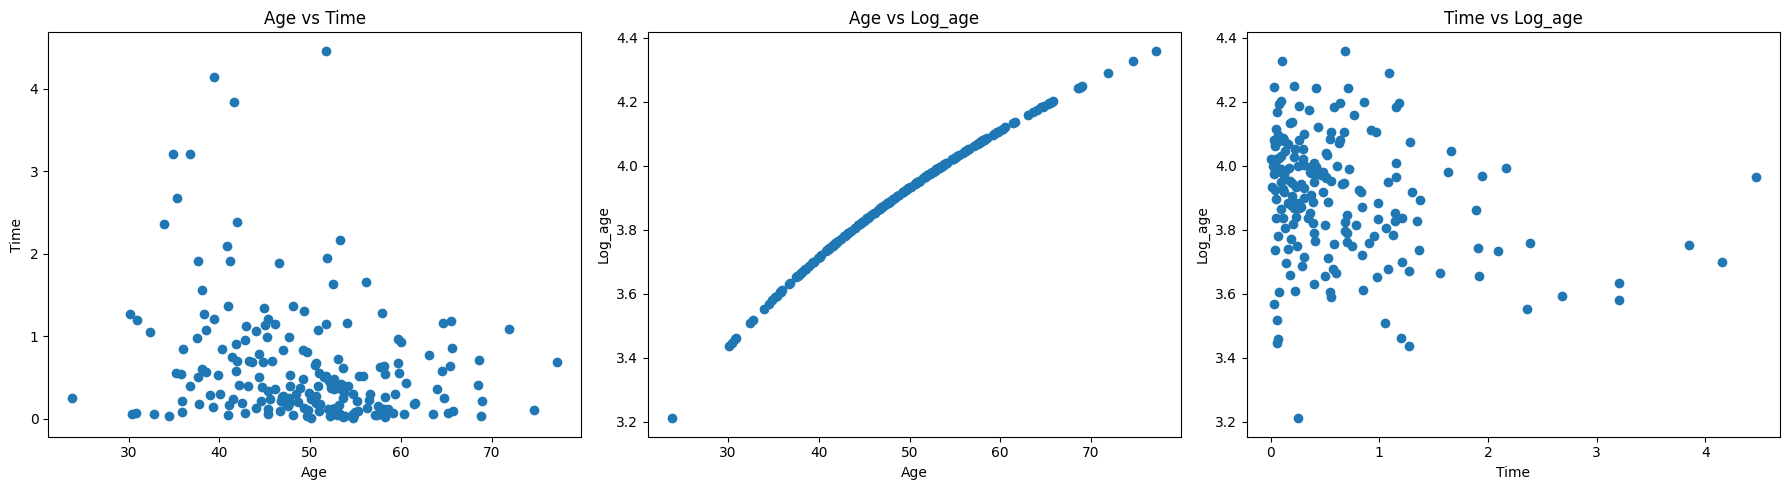

In [67]:
cols = ['Age', 'Time', 'Log_age']

pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Create one figure with subplots
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))

# Make axes iterable when n == 1
if n == 1:
    axes = [axes]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_sd[x], df_sd[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

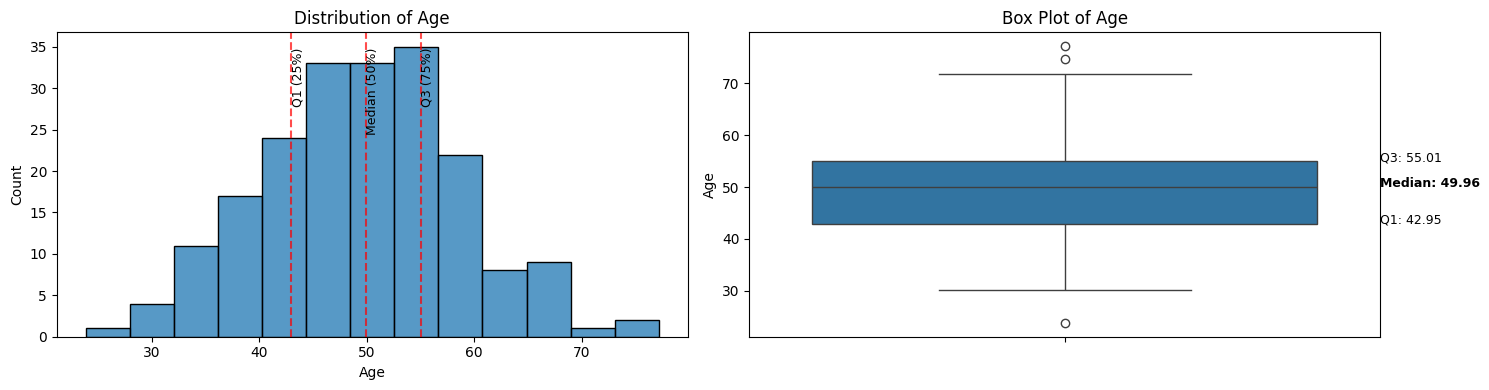

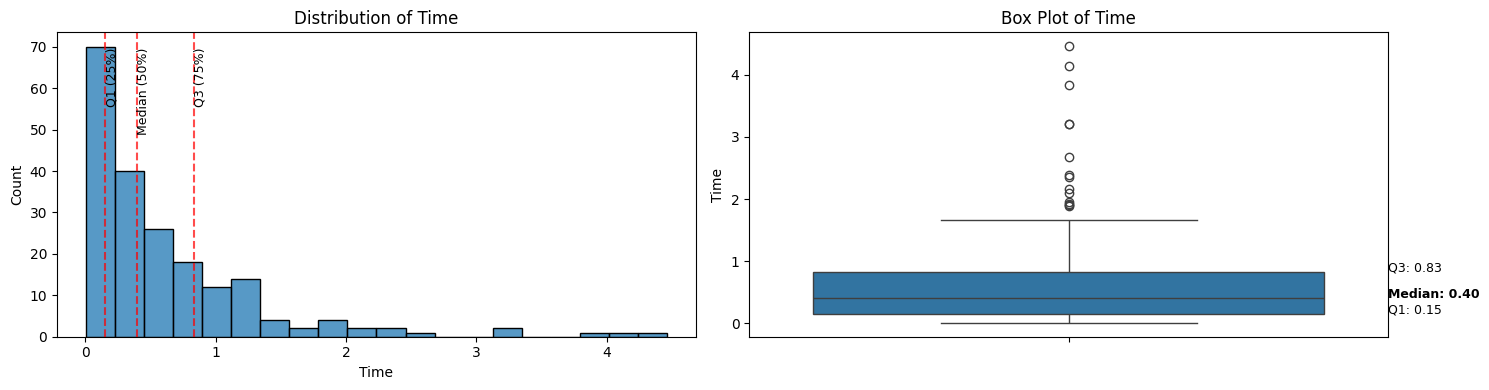

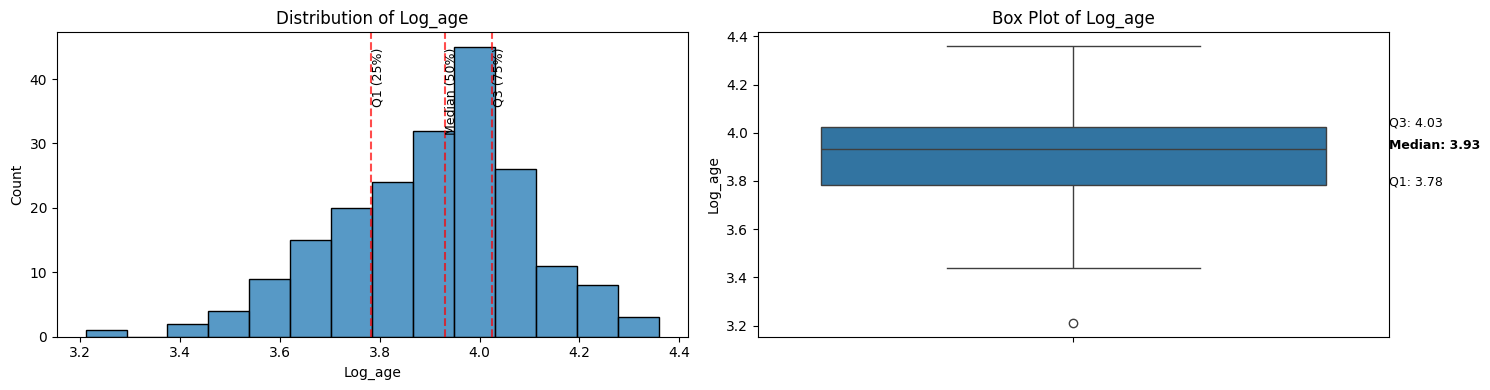

In [68]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms with quantiles
    sns.histplot(data=df_sd, x=col, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_sd[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
    
    # Plot 2: Box plot (fixed - removed duplicate x and y)
    sns.boxplot(data=df_sd, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    # Add quantile values as text on boxplot
    q1, median, q3 = df_sd[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

In [69]:
df_sd[cols].corr().abs()

,Age,Time,Log_age
Age,1.000000,0.250167,0.991009
Time,0.250167,1.000000,0.254205
Log_age,0.991009,0.254205,1.000000


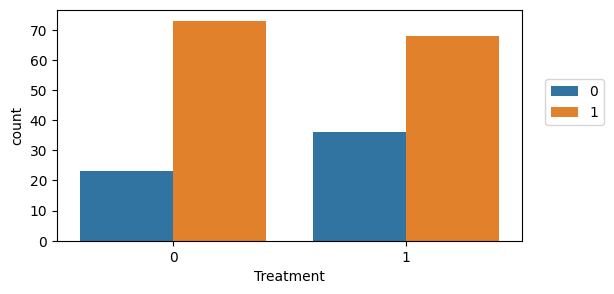

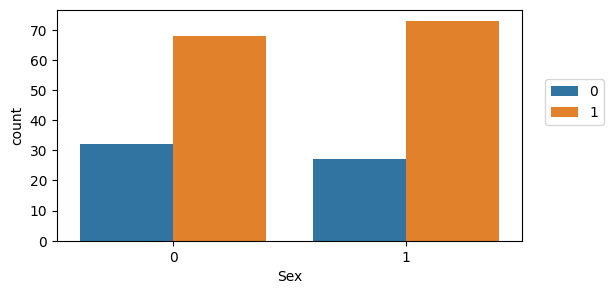

In [70]:
cols_qualitative = ['Treatment', 'Sex']

for col in cols_qualitative:
    plt.figure(figsize=(6,3), dpi=100)
    sns.countplot(data=df_sd, x=col, hue='Event')
    plt.legend(loc=(1.05, 0.5))
    plt.show()


In [71]:
df_sd = df_sd.drop('Log_age', axis=1)

#### Modelling

In [72]:
T = df_sd['Time']
E = df_sd['Event']

survival_table_from_events(T,E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.000000,0,0,0,200,200
0.004059,1,1,0,0,200
0.010749,1,1,0,0,199
0.022113,1,0,1,0,198
0.026174,1,0,1,0,197
...,...,...,...,...,...
3.205239,1,1,0,0,5
3.206745,1,0,1,0,4
3.845280,1,1,0,0,3


<Axes: xlabel='timeline'>

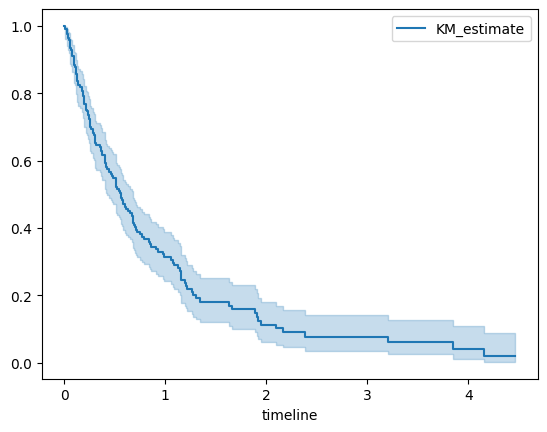

In [73]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()

In [74]:
kmf.survival_function_

,KM_estimate
timeline,
0.000000,1.000000
0.004059,0.995000
0.010749,0.990000
0.022113,0.990000
0.026174,0.990000
...,...
3.205239,0.062044
3.206745,0.062044
3.845280,0.041362


In [75]:
wft = WeibullAFTFitter()
wft.fit(df_sd, duration_col='Time', event_col='Event')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
   number of observations = 200
number of events observed = 141
           log-likelihood = -105.22
         time fit was run = 2026-02-06 04:50:37 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Age       -0.04      0.96      0.01           -0.06           -0.03                0.94                0.97
        Sex       -0.25      0.78      0.17           -0.58            0.07                0.56                1.07
        Treatment  0.50      1.65      0.16            0.18            0.81                1.20                2.25
        Intercept  1.92      6.80      0.46            1.02            2.81                2.77               16.69
rho_    Intercept  0.05      1.05      0.06           -0.08            0.18                0.93                1.19

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Age          0.00 -5.46 <0.005     24.35
        Sex          0.00 -1.53   0.13      2.98
        Treatment    0.00  3.10 <0.005      9.02
        Intercept    0.00  4.18 <0.005     15.09
rho_    Intercept    0.00  0.76   0.45      1.17
---
Concordance = 0.64
AIC = 220.44
log-likelihood ratio test = 36.39 on 3 df
-log2(p) of ll-ratio test = 23.95

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

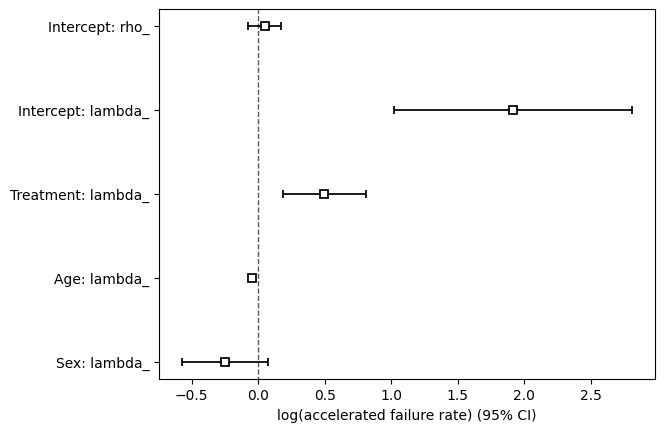

In [76]:
wft.plot()

In [77]:
# saving the dataframe
df_sd.to_csv(r'./data/preprocess-data/preprocess_simulated_data.csv')

In [78]:
cph = CoxPHFitter()
cph.fit(df_sd, duration_col='Time', event_col='Event', strata=['Treatment' ,'Sex', ])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                   strata = ['Treatment', 'Sex']
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -405.34
         time fit was run = 2026-02-06 04:50:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Age        0.04      1.05      0.01            0.03            0.06                1.03                1.06

           cmp to    z      p  -log2(p)
covariate                              
Age          0.00 4.98 <0.005     20.56
---
Concordance = 0.65
Partial AIC = 812.67
log-likelihood ratio test = 23.95 on 1 df
-log2(p) of ll-ratio test = 19.95


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4300)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9466)'>]]

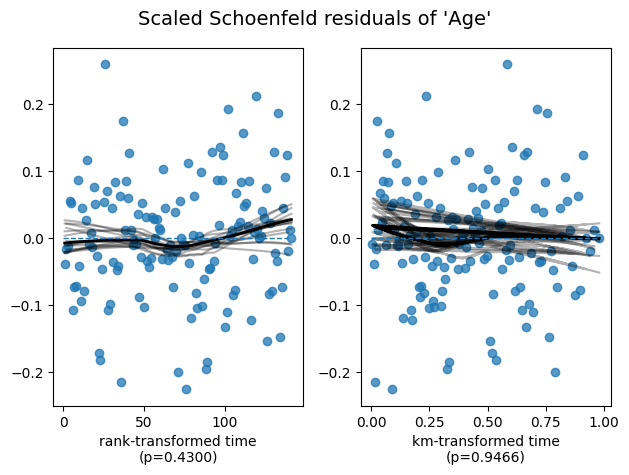

In [79]:
cph.check_assumptions(df_sd, show_plots=True, p_value_threshold=0.05)

In [80]:
scores = k_fold_cross_validation(
    cph, df_sd, duration_col='Time', event_col='Event', k=5
)

print("Average C-index:", np.mean(scores))

Average C-index: -1.0278644377013222


In [81]:
pred = cph.predict_partial_hazard(df_sd)
c_index_hm = concordance_index(df_sd["Time"], -pred, df_sd["Event"])
print("CoxPH C-index:", c_index_hm)

CoxPH C-index: 0.6412972972972973


In [82]:
ibs_sd = compute_ibs(
    cph=cph,
    df=df_sd,
    duration_col="Time",
    event_col="Event"
)

print("CoxPH IBS:", ibs_sd)

CoxPH IBS: 0.12534802253002192


In [83]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 594.1253860892712
